In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
from pathlib import Path

In [2]:
YEAR = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{YEAR}')

# Load data

In [3]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet").reset_index(drop=True)
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet").reset_index(drop=True)

print(f"# rows: {len(raw_Xy)}")
raw_Xy.head(1)

# rows: 915540


,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,red_11x11_median,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
0,0.121569,0.121569,0.109804,0.129412,0.007843,0.117647,0.109804,0.129412,0.007843,0.117647,...,-0.230769,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099


# Train:test:split

In [4]:
# Decide on which region to train for
REGION = 'Ashanti'
region_mask = raw_Xy.region == REGION

# Discard not-in-region data
raw_Xy = raw_Xy[region_mask]
metadata_df = metadata_df[region_mask]
print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")

# Figure out which folds are for train/val and which for test
test_size = 0.2
region_fold_idxs = metadata_df[region_mask].fold_idx.unique()
n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")

# Split
Xy_train = raw_Xy[~test_mask]
metadata_df_train = metadata_df[~test_mask]
Xy_test = raw_Xy[test_mask]
metadata_df_test = metadata_df[test_mask]

Discarding out-of-region points: Kept 95807/915540 (10.46%)
200/1000 regions for testing (19218 points)


/tmp/ipykernel_20801/2021917556.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  region_fold_idxs = metadata_df[region_mask].fold_idx.unique()


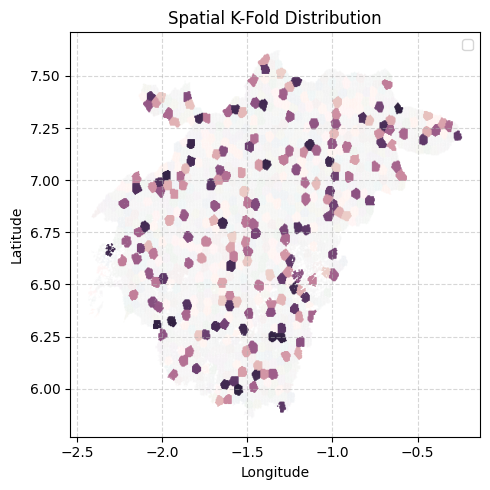

In [5]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=metadata_df[~test_mask], x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=metadata_df[test_mask], x='lon', y='lat', hue='fold_idx', color='r', s=1, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train models

In [6]:
# Build X,y
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Initialize and fit the Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train > 0.65)
yhat_test = dummy_clf.predict(X_test)

# Evaluate the baseline
print(f"Baseline Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print("- Negative (0)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print("- Positive (1)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")

Baseline Macro F1: 0.5003
Baseline Macro Precision: 0.5014
Baseline Macro Recall: 0.5015
- Negative (0)
- F1: 0.7475
-- Precision: 0.7691
-- Recall: 0.7270
- Positive (1)
- F1: 0.2531
-- Precision: 0.2337
-- Recall: 0.2761


# Prep hyperparam optimization

In [144]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import cross_validate, GroupKFold

def optuna_objective_factory(X, y, groups, n_splits: int = 100):
    gkf = GroupKFold(n_splits=n_splits)
    custom_cv = []
    
    # Generate the splits only on the rotating data
    for train_idx_rel, val_idx_rel in gkf.split(dummy_X_rot, dummy_X_rot, groups_rot):
        
        # Map the relative fold indices back to the absolute indices of the full dataset
        train_idx_rot = rot_indices[train_idx_rel]
        val_idx_rot = rot_indices[val_idx_rel]
        
        # Combine the fixed indices with the rotating training fold
        full_train_idx = np.concatenate([fixed_indices, train_idx_rot])
        
        # Append the (train, validation) tuple scikit-learn expects
        custom_cv.append((full_train_idx, val_idx_rot))

    # Pre-calculate the validation sizes for each fold
    val_sizes = [len(val_idx) for _, val_idx in custom_cv]

    # --- 2. The Objective Function ---
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        model = lgb.LGBMClassifier(**param)
        
        # Pass the pre-computed custom_cv list to the cv parameter
        scores = cross_validate(
            model, X, y, 
            cv=custom_cv, 
            scoring=['f1', 'precision', 'recall'], 
            n_jobs=1
        )
        
        trial.set_user_attr('f1s', scores["test_f1"])
        trial.set_user_attr('precisions', scores["test_precision"])
        trial.set_user_attr('recalls', scores["test_recall"])
        
        # Add the validation set sizes to the trial attributes
        trial.set_user_attr('val_sizes', val_sizes)
        
        return np.median(scores['test_f1'])

    return objective

# Train dummy LGBM baseline

In [132]:
def get_dummy_feature(X):
    features = ["valid_observations"]
    return X[features]
    
# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_dummy_feature(X_train)
X_test = get_dummy_feature(X_test)

X_train.head(1)

,valid_observations
523564,7


In [145]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, always_train_mask, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, always_train_mask), n_trials=n_trials, show_progress_bar=True)

    # Validation-inferred correction
    precision = (study.best_trial.user_attrs['precisions'] * np.array(user_attrs['val_sizes'])).sum() / sum(study.best_trial.user_attrs['val_sizes'])
    recall = (study.best_trial.user_attrs['recalls'] * np.array(user_attrs['val_sizes'])).sum() / sum(study.best_trial.user_attrs['val_sizes'])
    print(f"Area factor: {precision / recall:.2f}") 
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Area factor: {precision_score(y_test, yhat_test, zero_division=0) / recall_score(y_test, yhat_test, zero_division=0)}")

    return clf, yhat_train, yhat_test, study.best_trial.user_attrs

_, _, _, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

# Train LGBM baseline

In [146]:
# Baseline LGBM
def get_base_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_features(X_train)
X_test = get_base_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22
523564,0.035294,0.047059,0.054902,0.117647,0.090196,0.105882,0.086275,0.101961,0.156863,0.137255


In [ ]:
clf, yhat_train, yhat_test, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION, n_trials=1);

[I 2026-06-23 11:20:01,454] A new study created in memory with name: no-name-2a862ca0-1229-4bca-8b99-51ffda6e72f6


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
user_attrs['precisions'].mean() / user_attrs['recalls'].mean()

In [ ]:
np.median(user_attrs['precisions']) / np.median(user_attrs['recalls'])

In [ ]:
# Figure out map proportion
W_1 = yhat_test.sum()/len(yhat_test)
W_0 = 1 - W_cocoa


In [ ]:
n_11 = y

# Consider the SCL

In [57]:
# Take into account this SCL
def get_base_and_scl_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_features(X_train)
X_test = get_base_and_scl_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,scl
539860,0.031373,0.039216,0.047059,0.105882,0.078431,0.086275,0.070588,0.078431,0.113725,0.094118,UNCLASSIFIED


In [58]:
train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-23 09:36:19,633] A new study created in memory with name: no-name-64836034-76ad-4187-89ad-b22bd1da2cbf


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-23 09:36:21,709] Trial 0 finished with value: 0.6747311827956989 and parameters: {'n_estimators': 486, 'learning_rate': 0.08485273689641697, 'max_depth': 2, 'num_leaves': 163, 'subsample': 0.5184713479020266, 'colsample_bytree': 0.5842389044668106, 'min_child_samples': 32}. Best is trial 0 with value: 0.6747311827956989.
[I 2026-06-23 09:36:38,295] Trial 1 finished with value: 0.6860151849130541 and parameters: {'n_estimators': 361, 'learning_rate': 0.04514986562875007, 'max_depth': 11, 'num_leaves': 151, 'subsample': 0.6173216176922762, 'colsample_bytree': 0.9403860292778523, 'min_child_samples': 13}. Best is trial 1 with value: 0.6860151849130541.
[I 2026-06-23 09:36:41,265] Trial 2 finished with value: 0.6806218631411434 and parameters: {'n_estimators': 418, 'learning_rate': 0.05263397319230422, 'max_depth': 3, 'num_leaves': 10, 'subsample': 0.8540807909149071, 'colsample_bytree': 0.8904859071244574, 'min_child_samples': 91}. Best is trial 1 with value: 0.6860151849130541

# Add TCI & other features

In [59]:
# Take into account this SCL
def get_base_and_scl_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_advanced_features(X_train)
X_test = get_base_and_scl_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,scl,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
539860,0.031373,0.039216,0.047059,0.105882,0.078431,0.086275,0.070588,0.078431,0.113725,0.094118,UNCLASSIFIED,0.062353,0.2,0.037037,-0.234043,-0.148936,0.0,-0.047619,0.049702,-0.234043


In [60]:
train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-23 09:36:45,740] A new study created in memory with name: no-name-56eb47d8-01b3-42cd-a0ba-d0da9bb56215


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-23 09:37:01,616] Trial 0 finished with value: 0.6698278013476416 and parameters: {'n_estimators': 354, 'learning_rate': 0.1436466401882916, 'max_depth': 15, 'num_leaves': 106, 'subsample': 0.5403949172259392, 'colsample_bytree': 0.9481422969793902, 'min_child_samples': 70}. Best is trial 0 with value: 0.6698278013476416.
[I 2026-06-23 09:37:23,338] Trial 1 finished with value: 0.6765506807866868 and parameters: {'n_estimators': 236, 'learning_rate': 0.010173453886478558, 'max_depth': 14, 'num_leaves': 239, 'subsample': 0.7939670507567386, 'colsample_bytree': 0.5361619788147121, 'min_child_samples': 10}. Best is trial 1 with value: 0.6765506807866868.
[I 2026-06-23 09:37:28,848] Trial 2 finished with value: 0.6772022241732514 and parameters: {'n_estimators': 486, 'learning_rate': 0.014653990194586707, 'max_depth': 4, 'num_leaves': 49, 'subsample': 0.7815028416778012, 'colsample_bytree': 0.925964191898096, 'min_child_samples': 50}. Best is trial 2 with value: 0.677202224173251

# Keep track of #valid observations

In [61]:
# Take into account this SCL
def get_base_and_scl_and_obs_cnt_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations
539860,0.031373,0.039216,0.047059,0.105882,0.078431,0.086275,0.070588,0.078431,0.113725,0.094118,...,0.062353,0.2,0.037037,-0.234043,-0.148936,0.0,-0.047619,0.049702,-0.234043,5


In [62]:
train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-23 09:37:30,391] A new study created in memory with name: no-name-ea90cc29-c79d-4a0b-b990-4a8c8ae7c860


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-23 09:37:32,254] Trial 0 finished with value: 0.7009739787759849 and parameters: {'n_estimators': 143, 'learning_rate': 0.1447676079828597, 'max_depth': 4, 'num_leaves': 227, 'subsample': 0.6015443715514965, 'colsample_bytree': 0.608268374319854, 'min_child_samples': 65}. Best is trial 0 with value: 0.7009739787759849.
[I 2026-06-23 09:37:46,706] Trial 1 finished with value: 0.7031431897555297 and parameters: {'n_estimators': 198, 'learning_rate': 0.02151294171452944, 'max_depth': 11, 'num_leaves': 177, 'subsample': 0.5728680340328902, 'colsample_bytree': 0.8571256622574848, 'min_child_samples': 49}. Best is trial 1 with value: 0.7031431897555297.
[I 2026-06-23 09:38:01,908] Trial 2 finished with value: 0.7023255813953488 and parameters: {'n_estimators': 206, 'learning_rate': 0.022699443349412613, 'max_depth': 10, 'num_leaves': 214, 'subsample': 0.7471470883781031, 'colsample_bytree': 0.528563889244933, 'min_child_samples': 11}. Best is trial 1 with value: 0.7031431897555297

# Keep track of cloud confidence

In [63]:
# Take into account cloud confidence
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations,cloud_confidence
539860,0.031373,0.039216,0.047059,0.105882,0.078431,0.086275,0.070588,0.078431,0.113725,0.094118,...,0.2,0.037037,-0.234043,-0.148936,0.0,-0.047619,0.049702,-0.234043,5,0


In [64]:
clf, yhat_train, yhat_test, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-23 09:38:05,431] A new study created in memory with name: no-name-9ba9057d-50bd-4063-9feb-f9503dcb9cfa


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-23 09:38:11,920] Trial 0 finished with value: 0.6948165404775771 and parameters: {'n_estimators': 257, 'learning_rate': 0.022196889077543178, 'max_depth': 6, 'num_leaves': 122, 'subsample': 0.8167204047894618, 'colsample_bytree': 0.9257579557036157, 'min_child_samples': 96}. Best is trial 0 with value: 0.6948165404775771.
[I 2026-06-23 09:38:22,094] Trial 1 finished with value: 0.7064836448598131 and parameters: {'n_estimators': 312, 'learning_rate': 0.025947019639457836, 'max_depth': 12, 'num_leaves': 64, 'subsample': 0.7227787368079334, 'colsample_bytree': 0.6321547572768316, 'min_child_samples': 82}. Best is trial 1 with value: 0.7064836448598131.
[I 2026-06-23 09:38:29,245] Trial 2 finished with value: 0.7069141938313113 and parameters: {'n_estimators': 461, 'learning_rate': 0.04887648514060221, 'max_depth': 5, 'num_leaves': 190, 'subsample': 0.9693420394709158, 'colsample_bytree': 0.8093169197121052, 'min_child_samples': 52}. Best is trial 2 with value: 0.70691419383131

# Rely on neighbor pixels

In [65]:
# Take into account cloud confidence
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
539860,0.031373,0.039216,0.047059,0.105882,0.078431,0.086275,0.070588,0.078431,0.113725,0.094118,...,-0.357143,0.066735,0.225806,0.043103,-0.22449,-0.142857,0.02439,-0.045455,0.057794,-0.22449


In [66]:
clf, yhat_train, yhat_test, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, Xy_train.region != REGION);

[I 2026-06-23 09:38:31,242] A new study created in memory with name: no-name-75c224ea-5784-4b38-a161-a7dcaa72ea87


Starting Optuna hyperparameter optimization...


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-06-23 09:39:02,140] Trial 0 finished with value: 0.7839068290100583 and parameters: {'n_estimators': 227, 'learning_rate': 0.02127728972643647, 'max_depth': 14, 'num_leaves': 64, 'subsample': 0.5321144847810227, 'colsample_bytree': 0.6738062213412921, 'min_child_samples': 40}. Best is trial 0 with value: 0.7839068290100583.
[I 2026-06-23 09:40:08,473] Trial 1 finished with value: 0.7941422594142259 and parameters: {'n_estimators': 466, 'learning_rate': 0.019879589741701266, 'max_depth': 15, 'num_leaves': 81, 'subsample': 0.7735740430533063, 'colsample_bytree': 0.626313358922582, 'min_child_samples': 32}. Best is trial 1 with value: 0.7941422594142259.
[I 2026-06-23 09:40:22,722] Trial 2 finished with value: 0.7493595793447485 and parameters: {'n_estimators': 331, 'learning_rate': 0.021786521993855872, 'max_depth': 2, 'num_leaves': 26, 'subsample': 0.8172950949902598, 'colsample_bytree': 0.8442243032140793, 'min_child_samples': 74}. Best is trial 1 with value: 0.7941422594142259

# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?